# Baseline Model: Logistic Regression

## Introduction

### Motivation

Before evaluating more complex models such as autoencoders, we establish a **supervised baseline classifier** using Logistic Regression. This model provides a strong statistical reference point because it is:

- Interpretable
- Computationally efficient
- Well-understood theoretically
- A standard benchmark for tabular classification problems

The purpose of this baseline is to measure how well a classical linear model can distinguish between normal and attack network traffic in the RT-IoT 2022 dataset (Hastie et al., 2009).

### Model Formulation

Logistic Regression models the probability that an observation belongs to the attack class given a feature vector $x \in \mathbb{R}^d$. The model assumes a linear relationship between features and the log-odds of the outcome:

$$
P(y = 1 \mid x) = \sigma(w^\top x + b)
$$

where

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

is the sigmoid function, \(w\) represents model coefficients, and \(b\) is the intercept.

Equivalently, Logistic Regression models the log-odds (logit) as a linear function:

$$
\log \frac{P(y=1 \mid x)}{P(y=0 \mid x)} = w^\top x + b
$$

### Optimization Objective

Model parameters are learned by minimizing the regularized negative log-likelihood (logistic loss):

$$
\mathcal{L}(w,b)
=
-\frac{1}{n}
\sum_{i=1}^{n}
\left[
y_i \log(p_i) + (1-y_i)\log(1-p_i)
\right]
+ \lambda \|w\|_2^2
$$

where

$$
p_i = \sigma(w^\top x_i + b)
$$

and $\lambda \|w\|_2^2$ represents L2 regularization, which discourages excessively large coefficients and improves generalization.

The optimization is solved numerically using gradient-based methods (LBFGS in scikit-learn) (Hastie et al., 2009).

## Baseline Model & Model Selection

We began with the log-scaled feature matrix from the EDA section and a binary target label indicating normal versus attack traffic. The data were split into training, validation, and test partitions, with the **training set further stratified and downsampled to 25% of its original size** for computational feasibility while preserving the class distribution, as shown in @tbl-rtiot-lr-train-val-test-split. This downsampling choice reduced the cost of repeated model fitting during feature selection without altering the validation and test sets used for final assessment.

In [1]:
#| output: false

import sys
from pathlib import Path
# Set to root for src load
root = Path.cwd()
while root != root.parent and not (root / "src").exists():
    root = root.parent

if not (root / "src").exists():
    raise FileNotFoundError("Could not find 'src' folder above current working directory.")

sys.path.insert(0, str(root))
print("Project root:", root)

Project root: c:\Users\joetn\Real-Time_IoT_2022_Quantized_Auto_Encoder


In [2]:
from src.preprocessing import stratified_train_val_test_split
from src.baseline_lr import stepwise_bic_bidirectional
from src.eval_lr import tune_threshold_max_f1_attack_lr, fit_tune_evaluate_lr

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.sm_exceptions import ConvergenceWarning

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import roc_curve, auc, roc_auc_score


In [3]:
# Path from notebooks/ → project root → data/processed
processed_dir = Path("../data/processed")

# Load datasets from EDA
X_all = pd.read_csv(processed_dir / "X_all.csv")
y_bin = pd.read_csv(processed_dir / "y_bin.csv")["target"]

In [4]:
# Set plt plotting configs
plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "legend.title_fontsize": 9,
    "legend.frameon": True,
    "legend.borderpad": 0.3
})

In [5]:
#| label: tbl-rtiot-lr-train-val-test-split
#| tbl-cap: "Stratified train, validation, and test split. The training set is stratified and downsampled to 25% of its original size to reduce training time while preserving the class distribution. Validation and test sets remain unchanged for unbiased model evaluation."

# Split dataset into train, val, test with downsampling to 50%
(X_train, y_train), (X_val, y_val), (X_test, y_test) = stratified_train_val_test_split(
    X_all,
    y_bin,
    train_size=0.70,
    val_size=0.15,
    test_size=0.15,
    downsample_train=0.25,
    random_state=42
)

dist_df = pd.DataFrame({
    "split": ["train", "val", "test"],
    "rows": [len(y_train), len(y_val), len(y_test)],
    "attack_rate": [
        y_train.mean(),
        y_val.mean(),
        y_test.mean()
    ]
})

display(dist_df)

,split,rows,attack_rate
0,train,21545,0.898399
1,val,18468,0.898419
2,test,18468,0.898419


To reduce dimensionality and stabilize the baseline logistic regression workflow, we first fit an **L1-regularized (Lasso)** logistic regression pipeline with scaling, then applied **bidirectional stepwise selection using the BIC criterion** on the reduced feature set from Lasso, again using scaled predictors for numerical stability. The accepted stepwise path is summarized in @tbl-rtiot-lr-stepwise-history. Starting from the intercept-only model, BIC dropped sharply from ~14,168.8 to 1,779.2, yielding a final 9-feature subset: 

    - fwd_iat.min
    - flow_iat.min
    - bwd_iat.avg
    - active.std
    - flow_pkts_per_sec
    - bwd_pkts_payload.min
    - fwd_header_size_min
    - id.orig_p
    - flow_ECE_flag_count 
    
Practically, this indicates that a compact set of **timing, packet-rate, payload, header, port, and flag-based variables captured most of the predictive signal** needed by this baseline linear classifier (for comparison with autoencoder models).

In [6]:
#| output: false

# L1 (lasso) pipe with scaling
lasso_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LogisticRegressionCV(
        solver="saga",
        l1_ratios=(1,),      
        Cs=5,
        cv=3,
        scoring="roc_auc",
        max_iter=5000,
        class_weight="balanced",
        n_jobs=-1,
        refit=True,
        use_legacy_attributes=False
    ))
])

# Fit lasso pipe
lasso_pipe.fit(X_train, y_train)

# Extract selected features + coefficients
lasso_model = lasso_pipe.named_steps["lasso"]
coef = lasso_model.coef_.ravel()  # shape (n_features,)
feature_names = list(X_train.columns) 
lasso_selected = list(np.array(feature_names)[coef != 0])

# Lasso selected feature subsets
Xtr_lasso = X_train[lasso_selected]
Xva_lasso = X_val[lasso_selected]
Xte_lasso = X_test[lasso_selected]


print("LASSO-selected features:", len(lasso_selected))

c:\Users\joetn\anaconda3\envs\rt_iot_22\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LASSO-selected features: 23


In [7]:
#| output: false

# Run bidirectional BIC stepwise on lasso selected, scaled training set
stepwise_result = stepwise_bic_bidirectional(
    Xtr_lasso,                
    y_train,   
    max_steps=200,
    min_improve=1e-6,
    verbose=True
)

stepwise_selected = stepwise_result["selected_features"]

# Stepwise selected feature subsets
Xtr_final = X_train[stepwise_selected]
Xva_final = X_val[stepwise_selected]
Xte_final = X_test[stepwise_selected]

print("Selected features:", stepwise_selected)
print("Final BIC:", stepwise_result["bic"])

Start BIC: 14168.801 | selected=0
Step 1: add fwd_iat.min -> BIC 3776.159 (current 14168.801)
Step 2: add flow_iat.min -> BIC 2898.127 (current 3776.159)
Step 3: add bwd_iat.avg -> BIC 2477.022 (current 2898.127)
Step 4: add active.std -> BIC 2132.622 (current 2477.022)
Step 5: add flow_pkts_per_sec -> BIC 1985.318 (current 2132.622)
Step 6: add bwd_pkts_payload.min -> BIC 1917.826 (current 1985.318)
Step 7: add fwd_header_size_min -> BIC 1813.276 (current 1917.826)
Step 8: add id.orig_p -> BIC 1788.618 (current 1813.276)
Step 9: add flow_ECE_flag_count -> BIC 1779.190 (current 1788.618)
Step 10: add flow_FIN_flag_count -> BIC 1781.724 (current 1779.190)
No BIC improvement. Stop.
Selected features: ['fwd_iat.min', 'flow_iat.min', 'bwd_iat.avg', 'active.std', 'flow_pkts_per_sec', 'bwd_pkts_payload.min', 'fwd_header_size_min', 'id.orig_p', 'flow_ECE_flag_count']
Final BIC: 1779.19026103459


In [8]:
#| label: tbl-rtiot-lr-stepwise-history
#| tbl-cap: "Bidirectional stepwise BIC feature-selection path starting from the intercept-only logistic regression model."

stepwise_history = pd.DataFrame(stepwise_result["history"]).drop(columns=["selected_features"])

display(stepwise_history.style.hide(axis="index"))

step,action,feature,bic,delta_bic,n_selected
0,start,nan,14168.800776,nan,0
1,add,fwd_iat.min,3776.158982,-10392.641794,1
2,add,flow_iat.min,2898.127040,-878.031942,2
3,add,bwd_iat.avg,2477.022487,-421.104553,3
4,add,active.std,2132.621888,-344.400599,4
5,add,flow_pkts_per_sec,1985.317551,-147.304337,5
6,add,bwd_pkts_payload.min,1917.826027,-67.491524,6
7,add,fwd_header_size_min,1813.276007,-104.550020,7
8,add,id.orig_p,1788.617733,-24.658273,8
9,add,flow_ECE_flag_count,1779.190261,-9.427472,9


To directly compare them, we then fit and tuned three logistic regression variants: the full/saturated baseline model, the LASSO-selected subset, and the stepwise-selected subset. The classification threshold for each model was **tuned on the validation set to maximize F1 for the attack class**, and final performance was compared on the held-out test set using accuracy, precision, recall, ROC-AUC, PR-AUC, and F1, as summarized in @tbl-rtiot-lr-model-comparison. Confusion matrices were also retained in @tbl-rtiot-lr-confusion-matrix to make the false-positive versus false-negative tradeoff explicit. This evaluation setup provided a consistent basis for comparing discrimination performance across all three models with **ROC-AUC and PR-AUC being the primary metrics of our evaluation** for imbalanced anomaly detection systems. This again highlights that a compact set of features in the stepwise selected model captured most of the predictive signal.

In [9]:
# Baseline: all features
baseline_artifacts = fit_tune_evaluate_lr(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    model_name="baseline_lr"
)

# LASSO: lasso-selected features
lasso_artifacts = fit_tune_evaluate_lr(
    X_train[lasso_selected],
    y_train,
    X_val[lasso_selected],
    y_val,
    X_test[lasso_selected],
    y_test,
    model_name="lasso_lr"
)

# Stepwise: stepwise-selected features
stepwise_artifacts = fit_tune_evaluate_lr(
    X_train[stepwise_selected],
    y_train,
    X_val[stepwise_selected],
    y_val,
    X_test[stepwise_selected],
    y_test,
    model_name="stepwise_lr"
)

In [10]:
#| label: tbl-rtiot-lr-model-comparison
#| tbl-cap: "Validation-tuned and test-set performance comparison of the baseline, LASSO-reduced, and stepwise-selected logistic regression models."

comparison_df = pd.DataFrame([
    baseline_artifacts["results"],
    lasso_artifacts["results"],
    stepwise_artifacts["results"],
])

display(comparison_df.style.hide(axis="index"))

model,n_features,threshold,val_f1,test_roc_auc,test_pr_auc,test_accuracy,test_precision,test_recall,test_f1
baseline_lr,103,0.070000,0.996806,0.999055,0.999898,0.994964,0.997527,0.996866,0.997197
lasso_lr,23,0.060000,0.996836,0.996772,0.999587,0.994477,0.997706,0.996143,0.996924
stepwise_lr,9,0.050000,0.996625,0.996560,0.999626,0.994423,0.997466,0.996324,0.996894


In [11]:
#| label: tbl-rtiot-lr-confusion-matrix
#| tbl-cap: "Confusion matrices for the baseline, LASSO-reduced, and stepwise-selected logistic regression models evaluated on the held-out test set using the validation-tuned classification thresholds."

cm_rows = []

for name, art in [
    ("baseline_lr", baseline_artifacts),
    ("lasso_lr", lasso_artifacts),
    ("stepwise_lr", stepwise_artifacts),
]:

    cm = art["confusion_matrix"]

    cm_rows.append({
        "model": name,
        "TN": cm[0,0],
        "FP": cm[0,1],
        "FN": cm[1,0],
        "TP": cm[1,1],
    })

cm_df = pd.DataFrame(cm_rows)

display(cm_df.style.hide(axis="index"))

model,TN,FP,FN,TP
baseline_lr,1835,41,52,16540
lasso_lr,1838,38,64,16528
stepwise_lr,1834,42,61,16531


Because the **stepwise-selected model was the most parsimonious and best-supported specification**, we refit it in statsmodels for diagnostic analysis. The final fit summary in @tbl-rtiot-lr-final-sm-logit-fit showed log-likelihood of approximately -839.71, AIC of ~1,699.41, BIC of ~1,779.19, and successful convergence. This is an important practical result, the final selected model converged cleanly and produced finite likelihood-based fit statistics.

The coefficient summary in @tbl-rtiot-lr-final-coef-summary showed generally plausible coefficient magnitudes and directions. In particular, several timing-related features such as flow_iat.min and bwd_iat.avg had negative coefficients, while flow_pkts_per_sec and bwd_pkts_payload.min had positive coefficients, indicating that packet timing and traffic intensity were key discriminators between normal and attack traffic flows. Most coefficients were stable and interpretable. The main exception was flow_ECE_flag_count, which exhibited an unusually large standard error despite a finite coefficient estimate. This pattern is consistent with a sparse or low-variance indicator-like feature and **should be interpreted cautiously, though it was still retained by the BIC search as a useful predictor**.

In [12]:
#| label: tbl-rtiot-lr-final-sm-logit-fit
#| tbl-cap: "Final statsmodels logistic regression fit using the stepwise-selected feature subset."

# Final feature subset from stepwise BIC
Xtr_final = X_train[stepwise_selected].copy()

# Scale training predictors for stable optimization
scaler_final = StandardScaler()
Xtr_final_s = pd.DataFrame(
    scaler_final.fit_transform(Xtr_final),
    columns=Xtr_final.columns,
    index=Xtr_final.index
)

# Add intercept
Xtr_final_sm = sm.add_constant(Xtr_final_s, has_constant="add")

# Fit final statsmodels logistic regression
with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)
    warnings.simplefilter("ignore", RuntimeWarning)

    final_sm_model = sm.Logit(y_train, Xtr_final_sm).fit(disp=False, maxiter=5000)

# Compact fit summary table
fit_summary = pd.DataFrame({
    "metric": [
        "n_train_rows",
        "n_features",
        "log_likelihood",
        "aic",
        "bic",
        "converged"
    ],
    "value": [
        Xtr_final_sm.shape[0],
        len(stepwise_selected),
        final_sm_model.llf,
        final_sm_model.aic,
        final_sm_model.bic,
        final_sm_model.mle_retvals.get("converged", None)
    ]
})

display(fit_summary.style.hide(axis="index"))

metric,value
n_train_rows,21545
n_features,9
log_likelihood,-839.705635
aic,1699.411271
bic,1779.190261
converged,True


In [13]:
#| label: tbl-rtiot-lr-final-coef-summary
#| tbl-cap: "Coefficient estimates and standard errors for the final stepwise-selected logistic regression model fitted with statsmodels."

final_sm_model.summary2().tables[1]

,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
const,6.052876,2.064253e+06,2.932235e-06,9.999977e-01,-4.045855e+06,4.045867e+06
fwd_iat.min,-0.376742,6.298874e-02,-5.981099e+00,2.216377e-09,-5.001975e-01,-2.532862e-01
flow_iat.min,-1.581502,6.497773e-02,-2.433915e+01,7.553566e-131,-1.708856e+00,-1.454148e+00
bwd_iat.avg,-1.946933,1.073298e-01,-1.813971e+01,1.548334e-73,-2.157295e+00,-1.736570e+00
active.std,0.690525,4.059956e-02,1.700819e+01,7.140937e-65,6.109513e-01,7.700987e-01
flow_pkts_per_sec,1.182500,1.590564e-01,7.434472e+00,1.049867e-13,8.707555e-01,1.494245e+00
bwd_pkts_payload.min,1.123098,9.728699e-02,1.154418e+01,7.899516e-31,9.324191e-01,1.313777e+00
fwd_header_size_min,0.940646,9.801824e-02,9.596640e+00,8.259286e-22,7.485335e-01,1.132758e+00
id.orig_p,0.563363,8.072033e-02,6.979199e+00,2.968678e-12,4.051543e-01,7.215722e-01
flow_ECE_flag_count,-6.466269,8.847643e+07,-7.308465e-08,9.999999e-01,-1.734106e+08,1.734106e+08


## Assumption Checking & Validation
**Multicollinearity improved substantially** after LASSO reduction and stepwise refinement. The final VIF table in @tbl-rtiot-lr-final-vif showed that most predictors had low VIF values, with only fwd_iat.min and bwd_iat.avg slightly above 5. This is acceptable in context because both variables represent related inter-arrival time behavior and some correlation is expected in flow-based network telemetry. More importantly, no predictor approached the level typically associated with severe multicollinearity as we observed in our previous EDA, so the final model appears structurally stable.

In [14]:
#| label: tbl-rtiot-lr-final-vif
#| tbl-cap: "Variance inflation factors (VIF) for the final stepwise-selected logistic regression predictors."

X_vif = Xtr_final_sm.copy()

vif_df = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})

# Sort by VIF
vif_df = vif_df.sort_values("VIF", ascending=False)

display(vif_df.style.hide(axis="index"))

feature,VIF
bwd_iat.avg,5.775211
fwd_iat.min,5.499405
bwd_pkts_payload.min,3.435348
fwd_header_size_min,3.012110
flow_iat.min,2.857306
flow_pkts_per_sec,1.821093
active.std,1.346072
id.orig_p,1.065869
flow_ECE_flag_count,1.025462
const,1.000000


**Influence diagnostics also supported the adequacy of the final model**. In @fig-rtiot-lr-cooks-distance, most observations had Cook’s distance values near zero, with only a small number of moderate spikes. The summary metrics in @tbl-rtiot-lr-cooks-distance-metrics showed a maximum Cook’s distance of roughly 0.148 and a near-zero mean, indicating that no individual observation exerted excessive influence on the fitted model. This suggests **the model is not being driven by a handful of anomalous flows**, which is especially important in intrusion detection settings where rare but extreme traffic patterns are common.

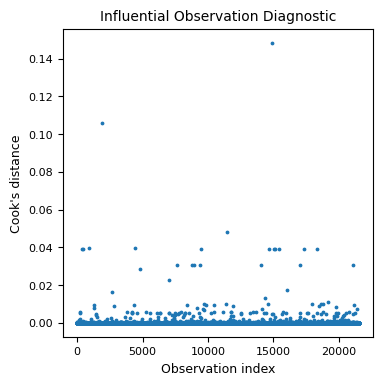

In [15]:
#| label: fig-rtiot-lr-cooks-distance
#| fig-cap: "Cook's distance for observations in the final logistic regression model."

influence = final_sm_model.get_influence()

cooks = influence.cooks_distance[0]
leverage = influence.hat_matrix_diag

n = len(cooks)

plt.figure(figsize=(4,4))
plt.scatter(range(n), cooks, s=3)

plt.xlabel("Observation index")
plt.ylabel("Cook's distance")
plt.title("Influential Observation Diagnostic")
plt.show()

In [16]:
#| label: tbl-rtiot-lr-cooks-distance-metrics
#| tbl-cap: "Cook's distance summary for the final logistic regression model showing the maximum value, mean Cook's distance, and the conventional 4/n influence threshold."
pd.DataFrame({
    "max_cooks": cooks.max(),
    "mean_cooks": cooks.mean(),
    "threshold": 4/len(cooks)
}, index=[0])

,max_cooks,mean_cooks,threshold
0,0.148443,0.000083,0.000186


We next assessed the linearity of the logit assumption visually in @fig-rtiot-lr-logit-linearity. The selected predictors generally exhibited monotonic, approximately linear relationships with the fitted logit, with no strong U-shaped or systematically curved patterns. Some predictors showed discrete clustering, which is expected for network-derived count and header fields, and flow_ECE_flag_count again appeared sparse. Overall, the visual evidence suggests that the **linearity assumption is reasonable** for this specification.

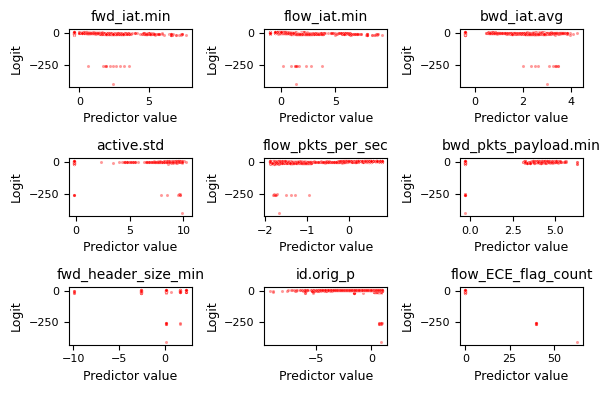

In [17]:
#| label: fig-rtiot-lr-logit-linearity
#| fig-cap: "Scatterplots of predictor values versus the logit of predicted probabilities used to visually assess the linearity-of-the-logit assumption for the final logistic regression model."

# predicted probabilities
p_hat = final_sm_model.predict(Xtr_final_sm)

# convert to logit
logit_hat = np.log(p_hat / (1 - p_hat))

fig, axes = plt.subplots(3, 3, figsize=(6,4))

axes = axes.flatten()

for i, col in enumerate(stepwise_selected):
    
    sns.scatterplot(
        x=Xtr_final_s[col],
        y=logit_hat,
        s=5,
        ax=axes[i],
        alpha=0.4,
        color="red"
    )
    
    axes[i].set_title(col)
    axes[i].set_xlabel("Predictor value")
    axes[i].set_ylabel("Logit")

plt.tight_layout()
plt.show()

Finally, the residual diagnostics indicated acceptable model fit. The deviance residual histogram in @fig-rtiot-lr-residual-hist was sharply centered near zero with symmetric but somewhat heavy tails, while the deviance residual scatterplot in @fig-rtiot-lr-deviance-residuals showed a dense band around zero and no obvious structure across observation range. A few larger residuals were present, but there was **no evidence of broad misspecification or systematic underfit**.

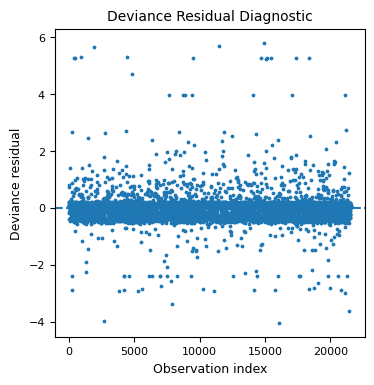

In [18]:
#| label: fig-rtiot-lr-deviance-residuals
#| fig-cap: "Deviance residuals for the final logistic regression model."

resid_dev = final_sm_model.resid_dev

plt.figure(figsize=(4,4))
plt.scatter(range(len(resid_dev)), resid_dev, s=3)

plt.axhline(0, linestyle="--")
plt.xlabel("Observation index")
plt.ylabel("Deviance residual")
plt.title("Deviance Residual Diagnostic")

plt.show()

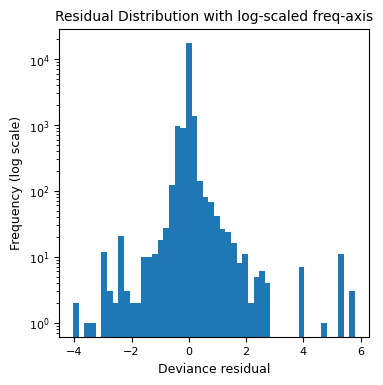

In [19]:
#| label: fig-rtiot-lr-residual-hist
#| fig-cap: "Distribution of deviance residuals for the final logistic regression model (log-scaled frequency axis)."

plt.figure(figsize=(4,4))
plt.hist(resid_dev, bins=50)

plt.yscale("log")  # expand tail visibility while keeping the peak

plt.xlabel("Deviance residual")
plt.ylabel("Frequency (log scale)")
plt.title("Residual Distribution with log-scaled freq-axis")

plt.show()

Overall, the BIC stepwise-selected baseline logistic regression model is statistically defensible and practically informative. The final stepwise model converged successfully, reduced the feature space to nine interpretable predictors, improved multicollinearity relative to the larger candidate set, showed no problematic influence behavior, satisfied the linearity-of-the-logit assumption reasonably well, and produced acceptable residual diagnostics. This gives us **a strong classical baseline against which the upcoming autoencoder-based anomaly detection models can be compared**.

In [20]:
# Save lr metrics to artifacts
artifact_dir = Path("../data/artifacts")
artifact_dir.mkdir(parents=True, exist_ok=True)

pd.DataFrame(comparison_df).to_csv(artifact_dir / "lr_model_comparison.csv", index=False)